# Seed-set quality: exploration and classification

This notebook explores the SBM dataset produced by `data_collection.py` and fits a simple classifier for high-quality seed sets. A seed set is labeled successful when its final unseeded matching accuracy is at least `SUCCESS_THRESHOLD`, which is set to 0.90 below and can be changed easily.

Observations from the same graph pair are kept together during model evaluation. The predictor set contains only quantities available before running SGM: Graph-1 seed-set summaries and permutation-invariant graph summaries. H0 and all SGM outputs are outcomes or diagnostics, not predictors.


In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import CalibrationDisplay
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    balanced_accuracy_score,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate

RANDOM_STATE = 42
SUCCESS_THRESHOLD = 0.90
plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True})


## Load the collected observations

In [54]:
DATA_PATH = Path("data/seed_quality_paper.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}. "
        "Start Jupyter from the Seeded-Graph-Matching project folder."
    )

df = pd.read_csv(DATA_PATH)

EXPECTED_FEATURE_SCHEMA_VERSION = 2
if "feature_schema_version" not in df.columns:
    raise ValueError(
        "This dataset uses the old feature schema. Refresh it with "
        "data_collection.py --features-only before running the notebook."
    )
schema_versions = set(df["feature_schema_version"].dropna().astype(int))
if schema_versions != {EXPECTED_FEATURE_SCHEMA_VERSION}:
    raise ValueError(
        f"Expected feature schema {EXPECTED_FEATURE_SCHEMA_VERSION}, "
        f"but found {sorted(schema_versions)}."
    )

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Graph pairs: {df['graph_pair_id'].nunique()}")
df.head()

Rows: 1,000
Columns: 176
Graph pairs: 20


,feature_schema_version,graph_model,graph_pair_key,graph_pair_id,candidate_id,graph_pair_seed,sgm_seed,seed_vertices_graph1,seed_vertices_graph2,n_vertices,...,seed_degree_median,seed_degree_q75,seed_degree_max,h0_accuracy,final_unseeded_accuracy,final_all_accuracy,sgm_runtime_seconds,sgm_n_iter,sgm_converged,sgm_objective_score
0,2,paper,paper_0,0,0,4206279609,77129228,"[60, 68, 80, 98, 140, 150, 155, 184, 186, 217,...","[225, 128, 578, 317, 123, 589, 316, 202, 512, ...",600,...,6.0,8.75,14.0,0.073684,0.271930,0.308333,1.142451,30,True,1570.0
1,2,paper,paper_0,0,1,4206279609,3999458005,"[51, 89, 101, 106, 166, 197, 208, 244, 246, 25...","[385, 582, 421, 142, 438, 593, 4, 562, 419, 24...",600,...,5.0,7.00,12.0,0.101754,0.957895,0.960000,0.961535,30,False,2480.0
2,2,paper,paper_0,0,2,4206279609,3140993309,"[3, 14, 16, 70, 120, 142, 143, 147, 153, 164, ...","[15, 581, 233, 135, 64, 216, 466, 588, 310, 7,...",600,...,5.5,8.00,13.0,0.084211,0.968421,0.970000,0.966577,30,False,2476.0
3,2,paper,paper_0,0,3,4206279609,2092581698,"[19, 39, 44, 104, 109, 122, 133, 152, 176, 180...","[341, 219, 1, 571, 166, 454, 570, 397, 395, 35...",600,...,5.5,6.75,12.0,0.080702,0.964912,0.966667,0.921544,29,True,2478.0
4,2,paper,paper_0,0,4,4206279609,4211593089,"[25, 53, 59, 60, 72, 78, 101, 218, 231, 288, 2...","[28, 165, 106, 225, 45, 145, 421, 598, 72, 61,...",600,...,5.0,6.75,14.0,0.089474,0.963158,0.965000,0.770505,24,True,2474.0


## Basic data checks and numerical summary

In [55]:
rows_per_pair = df.groupby("graph_pair_id").size()

print("Rows per graph pair:")
print(rows_per_pair.describe().to_string())
print(f"\nMissing cells: {int(df.isna().sum().sum())}")
print(
    "Duplicate graph-pair/candidate IDs:",
    int(df.duplicated(["graph_pair_id", "candidate_id"]).sum()),
)

performance_columns = [
    "h0_accuracy",
    "final_unseeded_accuracy",
    "final_all_accuracy",
    "sgm_runtime_seconds",
    "sgm_n_iter",
]
df[performance_columns].describe().T

Rows per graph pair:
count    20.0
mean     50.0
std       0.0
min      50.0
25%      50.0
50%      50.0
75%      50.0
max      50.0

Missing cells: 4000
Duplicate graph-pair/candidate IDs: 0


,count,mean,std,min,25%,50%,75%,max
h0_accuracy,1000.0,0.076795,0.015133,0.033333,0.066667,0.077193,0.087719,0.115789
final_unseeded_accuracy,1000.0,0.547925,0.377758,0.052632,0.164912,0.429825,0.961404,0.991228
final_all_accuracy,1000.0,0.570528,0.358870,0.100000,0.206667,0.458333,0.963333,0.991667
sgm_runtime_seconds,1000.0,0.911718,0.110853,0.457954,0.891624,0.941287,0.973373,1.348119
sgm_n_iter,1000.0,28.269000,3.305990,14.000000,28.000000,30.000000,30.000000,30.000000


## Accuracy and runtime distributions

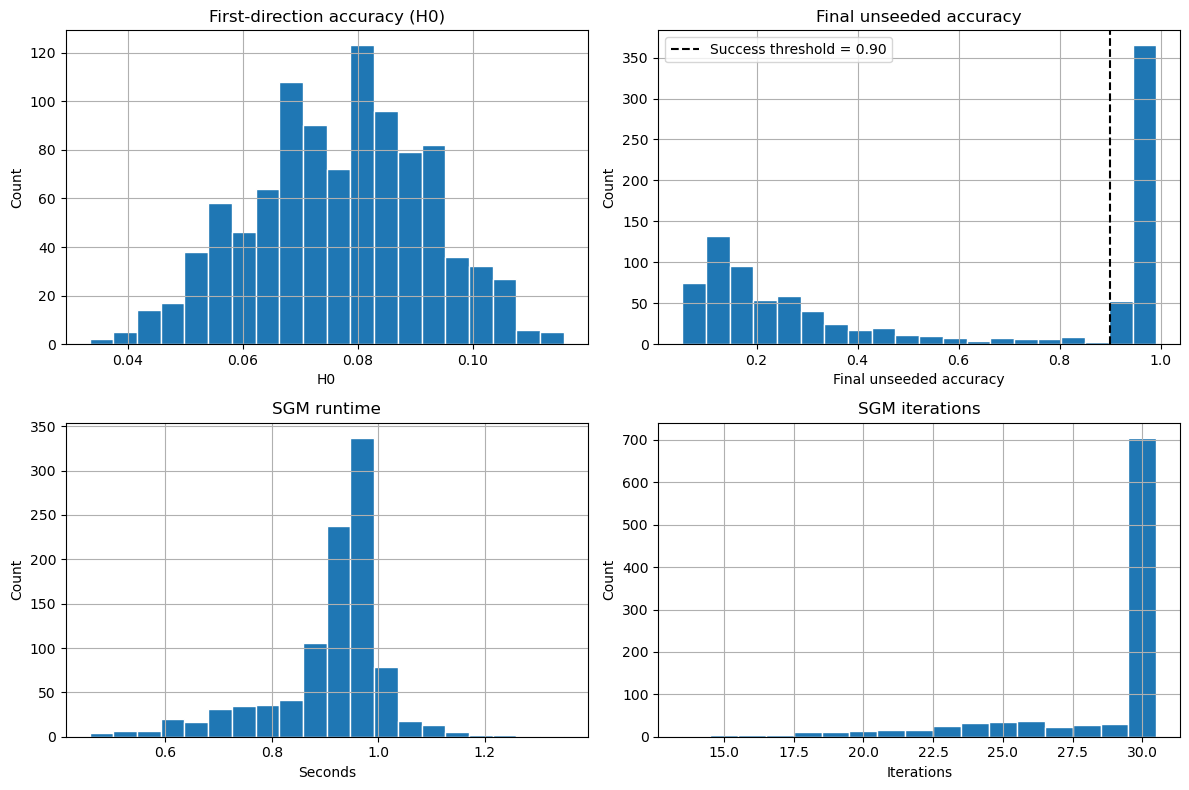

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df["h0_accuracy"], bins=20, edgecolor="white")
axes[0, 0].set(title="First-direction accuracy (H0)", xlabel="H0", ylabel="Count")

axes[0, 1].hist(df["final_unseeded_accuracy"], bins=20, edgecolor="white")
axes[0, 1].axvline(
    SUCCESS_THRESHOLD,
    color="black",
    linestyle="--",
    label=f"Success threshold = {SUCCESS_THRESHOLD:.2f}",
)
axes[0, 1].set(
    title="Final unseeded accuracy",
    xlabel="Final unseeded accuracy",
    ylabel="Count",
)
axes[0, 1].legend()

axes[1, 0].hist(df["sgm_runtime_seconds"], bins=20, edgecolor="white")
axes[1, 0].set(title="SGM runtime", xlabel="Seconds", ylabel="Count")

iteration_bins = np.arange(df["sgm_n_iter"].min(), df["sgm_n_iter"].max() + 2) - 0.5
axes[1, 1].hist(df["sgm_n_iter"], bins=iteration_bins, edgecolor="white")
axes[1, 1].set(title="SGM iterations", xlabel="Iterations", ylabel="Count")

fig.tight_layout()
plt.show()


## Relationship between H0 and final accuracy

H0 requires the simulated ground-truth permutation, so it cannot be used as a deployable pre-SGM feature. It is still useful for understanding how the first SGM direction relates to the final result.

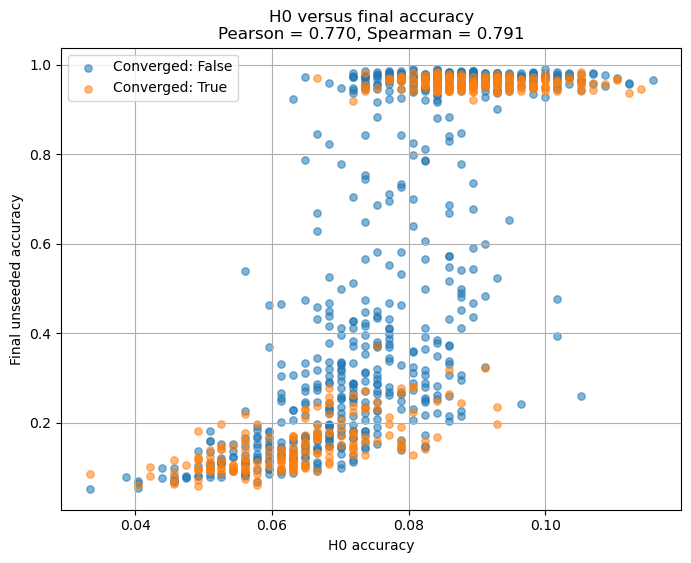

In [57]:
pearson_h0_final = df["h0_accuracy"].corr(df["final_unseeded_accuracy"])
spearman_h0_final = df["h0_accuracy"].corr(
    df["final_unseeded_accuracy"], method="spearman"
)

fig, ax = plt.subplots(figsize=(8, 6))
for converged, subset in df.groupby("sgm_converged"):
    ax.scatter(
        subset["h0_accuracy"],
        subset["final_unseeded_accuracy"],
        alpha=0.55,
        s=28,
        label=f"Converged: {converged}",
    )
ax.set(
    title=(
        f"H0 versus final accuracy\n"
        f"Pearson = {pearson_h0_final:.3f}, Spearman = {spearman_h0_final:.3f}"
    ),
    xlabel="H0 accuracy",
    ylabel="Final unseeded accuracy",
)
ax.legend()
plt.show()

In [46]:
df.assign(
    h0_quartile=pd.qcut(df["h0_accuracy"], 4, duplicates="drop")
).groupby("h0_quartile", observed=True).agg(
    observations=("h0_accuracy", "size"),
    mean_h0=("h0_accuracy", "mean"),
    mean_final_accuracy=("final_unseeded_accuracy", "mean"),
    median_final_accuracy=("final_unseeded_accuracy", "median"),
    high_quality_rate=(
        "final_unseeded_accuracy",
        lambda values: np.mean(values >= SUCCESS_THRESHOLD),
    ),
    perfect_matching_rate=(
        "final_unseeded_accuracy", lambda values: np.mean(values == 1.0)
    ),
)


/var/folders/ml/83krr6zn0h14r6frjc4353kh0000gn/T/ipykernel_60639/443948384.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.assign(


,observations,mean_h0,mean_final_accuracy,median_final_accuracy,high_quality_rate,perfect_matching_rate
h0_quartile,,,,,,
"(0.031599999999999996, 0.055]",288,0.049721,0.298367,0.184708,0.121528,0.006944
"(0.055, 0.0619]",279,0.059472,0.604084,0.542955,0.455197,0.057348
"(0.0619, 0.0687]",225,0.065788,0.820939,0.987973,0.737778,0.066667
"(0.0687, 0.0928]",208,0.075643,0.929669,0.991409,0.903846,0.105769


## Define the classification target and predictors

A seed set is labeled successful when final unseeded accuracy is at least 90%. Change `SUCCESS_THRESHOLD` near the top of the notebook if a different operational definition is more useful.

The model uses the existing numeric seed and graph summaries directly. IDs, parameter settings, seed lists, H0, and every output produced by SGM are excluded. Constant columns are also removed.


In [58]:
CONTINUOUS_OUTCOME = "final_unseeded_accuracy"
CLASS_TARGET = "seed_set_success"

df[CLASS_TARGET] = (df[CONTINUOUS_OUTCOME] >= SUCCESS_THRESHOLD).astype(int)

feature_prefixes = ("seed_", "nonseed_", "graph1_", "graph2_", "pair_")
feature_columns = [
    column
    for column in df.columns
    if column.startswith(feature_prefixes)
    and column != CLASS_TARGET
    and pd.api.types.is_numeric_dtype(df[column])
    and df[column].nunique(dropna=False) > 1
]

X = df[feature_columns].copy()
y = df[CLASS_TARGET].copy()
groups = df["graph_pair_id"].copy()

if y.nunique() != 2:
    raise ValueError(
        "The selected SUCCESS_THRESHOLD does not produce both success and failure "
        "classes. Choose a threshold within the observed accuracy range."
    )

print(f"Success rule: {CONTINUOUS_OUTCOME} >= {SUCCESS_THRESHOLD:.2f}")
print(f"Successful observations: {y.sum():,} of {len(y):,} ({y.mean():.1%})")
print(f"Predictors: {X.shape[1]}")
print(f"Missing predictor values: {int(X.isna().sum().sum())}")


Success rule: final_unseeded_accuracy >= 0.90
Successful observations: 418 of 1,000 (41.8%)
Predictors: 142
Missing predictor values: 0


/var/folders/ml/83krr6zn0h14r6frjc4353kh0000gn/T/ipykernel_60639/2937667682.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[CLASS_TARGET] = (df[CONTINUOUS_OUTCOME] >= SUCCESS_THRESHOLD).astype(int)


## Simple univariate associations

The correlations compare each feature with the binary success label. `single_feature_auc` measures how well one feature alone separates successful and unsuccessful sets, allowing either increasing or decreasing direction. Values near 0.5 show little separation; values closer to 1.0 show stronger separation. These results remain exploratory because many feature columns are closely related.


In [59]:
association_rows = []
for feature in feature_columns:
    raw_auc = roc_auc_score(y, X[feature])
    association_rows.append(
        {
            "feature": feature,
            "pearson_with_success": X[feature].corr(y),
            "spearman_with_success": X[feature].corr(y, method="spearman"),
            "failure_mean": X.loc[y == 0, feature].mean(),
            "success_mean": X.loc[y == 1, feature].mean(),
            "single_feature_auc": max(raw_auc, 1.0 - raw_auc),
        }
    )

association_df = pd.DataFrame(association_rows)
association_df["absolute_spearman"] = association_df[
    "spearman_with_success"
].abs()
association_df = association_df.sort_values("single_feature_auc", ascending=False)
association_df.head(15)


,feature,pearson_with_success,spearman_with_success,failure_mean,success_mean,single_feature_auc,absolute_spearman
69,nonseed_three_hop_seed_count_mean,0.633113,0.672239,6.309981,10.527730,0.893444,0.672239
72,nonseed_within_three_hops_of_three_seeds_fraction,0.551328,0.662245,0.737858,0.956887,0.887510,0.662245
65,nonseed_two_hop_seed_count_mean,0.635067,0.659462,1.390279,2.138387,0.885965,0.659462
67,nonseed_within_two_hops_of_two_seeds_fraction,0.620614,0.657350,0.372225,0.576740,0.884719,0.657350
68,nonseed_within_two_hops_of_three_seeds_fraction,0.639042,0.655636,0.189353,0.353055,0.883714,0.655636
70,nonseed_three_hop_seed_count_q10,0.647382,0.670771,1.940893,4.342105,0.880549,0.670771
126,nonseed_color_refinement_round_1_class_count,0.629759,0.650342,109.613402,137.674641,0.880549,0.650342
12,graph1_degree_mean,0.598207,0.650078,4.649181,5.879609,0.879713,0.650078
56,seed_neighborhood_column_entropy_mean,0.622027,0.639247,0.062807,0.078820,0.874135,0.639247
73,nonseed_nearest_seed_distance_mean,-0.584938,-0.637840,2.183467,1.918009,0.873311,0.637840


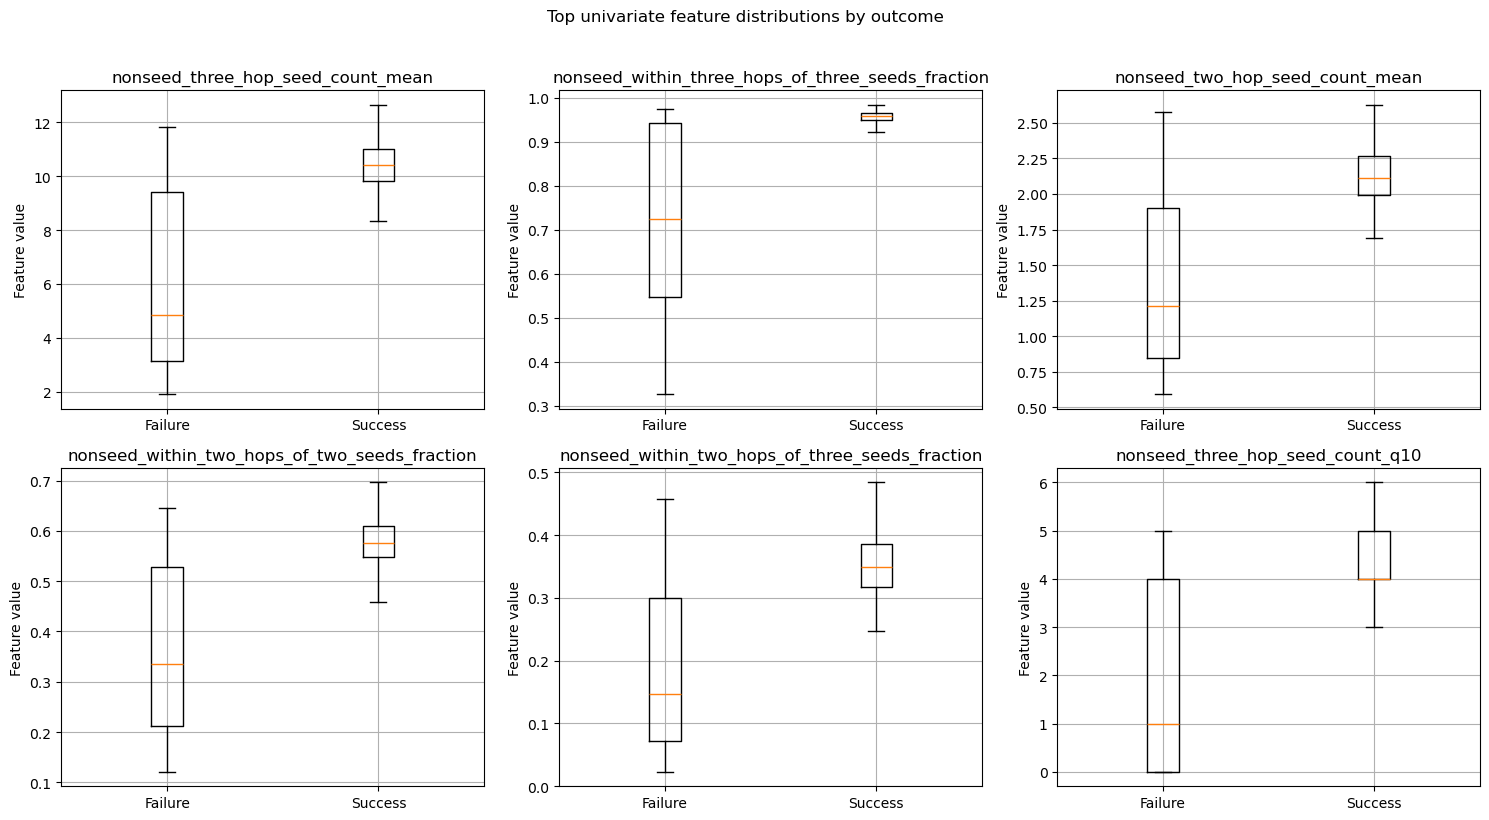

In [60]:
top_univariate_features = association_df.head(6)["feature"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feature in zip(axes.flat, top_univariate_features):
    ax.boxplot(
        [X.loc[y == 0, feature], X.loc[y == 1, feature]],
        tick_labels=["Failure", "Success"],
        showfliers=False,
    )
    ax.set(title=feature, ylabel="Feature value")

fig.suptitle("Top univariate feature distributions by outcome", y=1.02)
fig.tight_layout()
plt.show()


## Group-aware classification

The random forest can model nonlinear relationships without additional feature engineering. Five-fold cross-validation keeps every candidate from a graph pair entirely within one fold. The dummy classifier uses only the training-fold class proportions and provides a baseline.

Balanced accuracy gives equal weight to success and failure. ROC AUC measures ranking across probability thresholds, average precision emphasizes identification of successful seed sets, and log loss evaluates the predicted probabilities themselves.


In [61]:
model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=8,
    max_features=0.7,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
baseline = DummyClassifier(strategy="prior")

group_cv = GroupKFold(n_splits=5)
scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "log_loss": "neg_log_loss",
}


def summarize_cv(estimator, name):
    scores = cross_validate(
        estimator,
        X,
        y,
        groups=groups,
        cv=group_cv,
        scoring=scoring,
        n_jobs=1,
    )
    return {
        "model": name,
        "mean_balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "mean_ROC_AUC": scores["test_roc_auc"].mean(),
        "mean_average_precision": scores["test_average_precision"].mean(),
        "mean_log_loss": -scores["test_log_loss"].mean(),
    }


cv_summary = pd.DataFrame(
    [
        summarize_cv(baseline, "Class-prior baseline"),
        summarize_cv(model, "Random forest"),
    ]
)
cv_summary


,model,mean_balanced_accuracy,mean_ROC_AUC,mean_average_precision,mean_log_loss
0,Class-prior baseline,0.500000,0.500000,0.418000,0.711600
1,Random forest,0.771899,0.839489,0.828704,0.425219


## Held-out graph pairs and probability diagnostics

This produces one interpretable train/test example with one quarter of the graph pairs held out. The grouped cross-validation table above is the more stable estimate of performance.


In [62]:
splitter = GroupShuffleSplit(
    n_splits=1, test_size=0.25, random_state=RANDOM_STATE
)
train_index, test_index = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]
train_groups = set(groups.iloc[train_index])
test_groups = set(groups.iloc[test_index])

assert train_groups.isdisjoint(test_groups)
print(f"Training graph pairs: {len(train_groups)}")
print(f"Test graph pairs: {len(test_groups)}")
print(f"Training success rate: {y_train.mean():.1%}")
print(f"Test success rate: {y_test.mean():.1%}")

model.fit(X_train, y_train)
baseline.fit(X_train, y_train)

test_probability = model.predict_proba(X_test)[:, 1]
baseline_probability = baseline.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= 0.5).astype(int)
baseline_prediction = baseline.predict(X_test)


def heldout_metrics(name, prediction, probability):
    return {
        "model": name,
        "balanced_accuracy": balanced_accuracy_score(y_test, prediction),
        "ROC_AUC": roc_auc_score(y_test, probability),
        "average_precision": average_precision_score(y_test, probability),
        "log_loss": log_loss(y_test, probability, labels=[0, 1]),
    }


heldout_summary = pd.DataFrame(
    [
        heldout_metrics(
            "Class-prior baseline", baseline_prediction, baseline_probability
        ),
        heldout_metrics("Random forest", test_prediction, test_probability),
    ]
)
heldout_summary


Training graph pairs: 15
Test graph pairs: 5
Training success rate: 42.1%
Test success rate: 40.8%


,model,balanced_accuracy,ROC_AUC,average_precision,log_loss
0,Class-prior baseline,0.500000,0.500000,0.408000,0.676488
1,Random forest,0.765103,0.882618,0.802664,0.398935


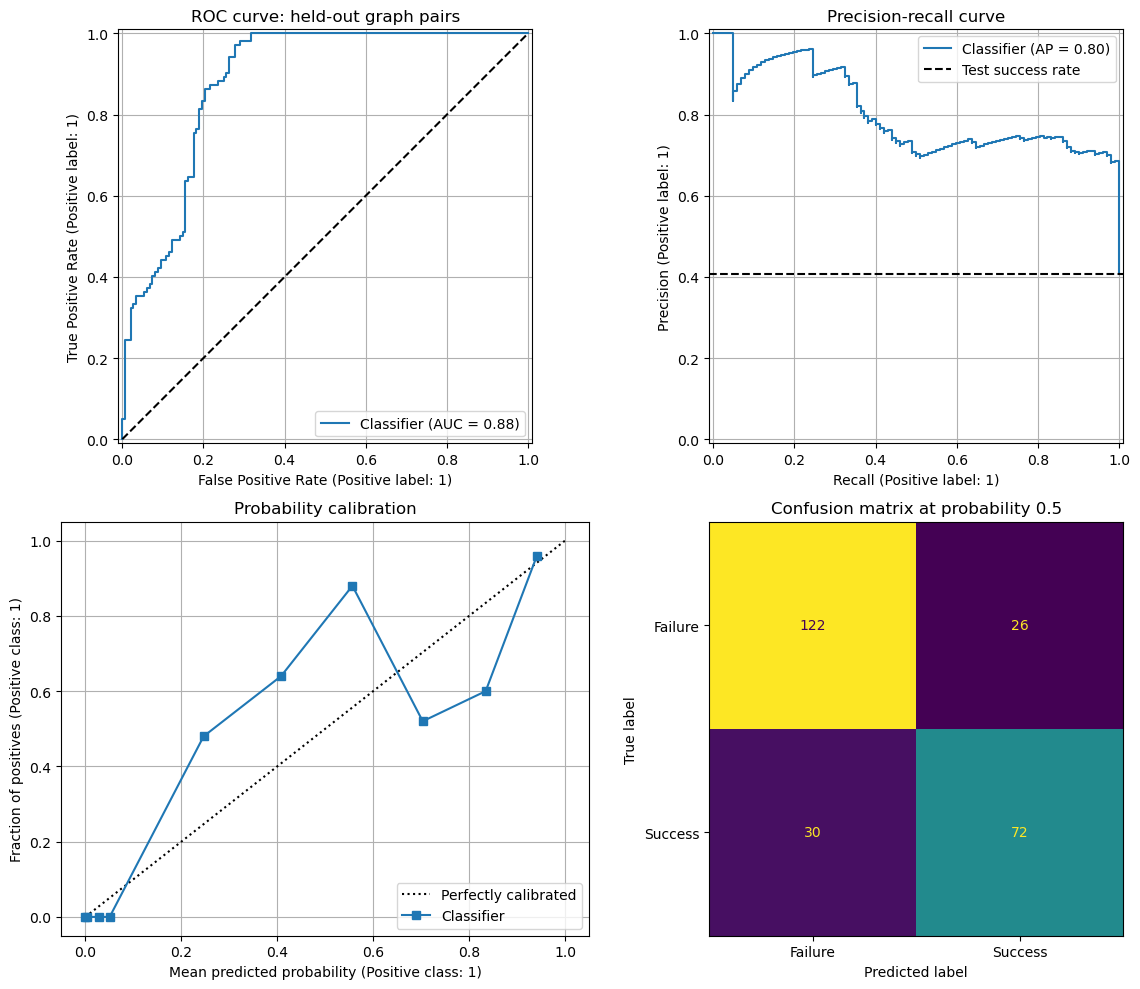

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

RocCurveDisplay.from_predictions(y_test, test_probability, ax=axes[0, 0])
axes[0, 0].plot([0, 1], [0, 1], linestyle="--", color="black")
axes[0, 0].set_title("ROC curve: held-out graph pairs")

PrecisionRecallDisplay.from_predictions(y_test, test_probability, ax=axes[0, 1])
axes[0, 1].axhline(
    y_test.mean(), linestyle="--", color="black", label="Test success rate"
)
axes[0, 1].legend()
axes[0, 1].set_title("Precision-recall curve")

CalibrationDisplay.from_predictions(
    y_test,
    test_probability,
    n_bins=10,
    strategy="quantile",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Probability calibration")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    display_labels=["Failure", "Success"],
    ax=axes[1, 1],
    colorbar=False,
)
axes[1, 1].grid(False)
axes[1, 1].set_title("Confusion matrix at probability 0.5")

fig.tight_layout()
plt.show()


## Exploratory permutation importance

Permutation importance measures how much held-out ROC AUC decreases when one feature is randomly shuffled. Interpret these values only if the classifier performs meaningfully better than the baseline. Strongly correlated features can divide their importance among several columns.


In [64]:
importance = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame(
    {
        "feature": feature_columns,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    }
).sort_values("importance_mean", ascending=False)
importance_df.head(15)


,feature,importance_mean,importance_std
69,nonseed_three_hop_seed_count_mean,0.011665,0.007544
133,nonseed_color_refinement_round_2_collision_pai...,0.001669,0.001397
100,nonseed_community_multi_coverage_mean,0.000772,0.000308
135,nonseed_color_refinement_round_2_normalized_en...,0.000560,0.000500
127,nonseed_color_refinement_round_1_unique_fraction,0.000550,0.001682
93,seed_community_normalized_entropy,0.000540,0.000565
126,nonseed_color_refinement_round_1_class_count,0.000437,0.000409
86,seed_clustering_mean,0.000404,0.000418
40,seed_induced_density,0.000397,0.000257
67,nonseed_within_two_hops_of_two_seeds_fraction,0.000388,0.000932


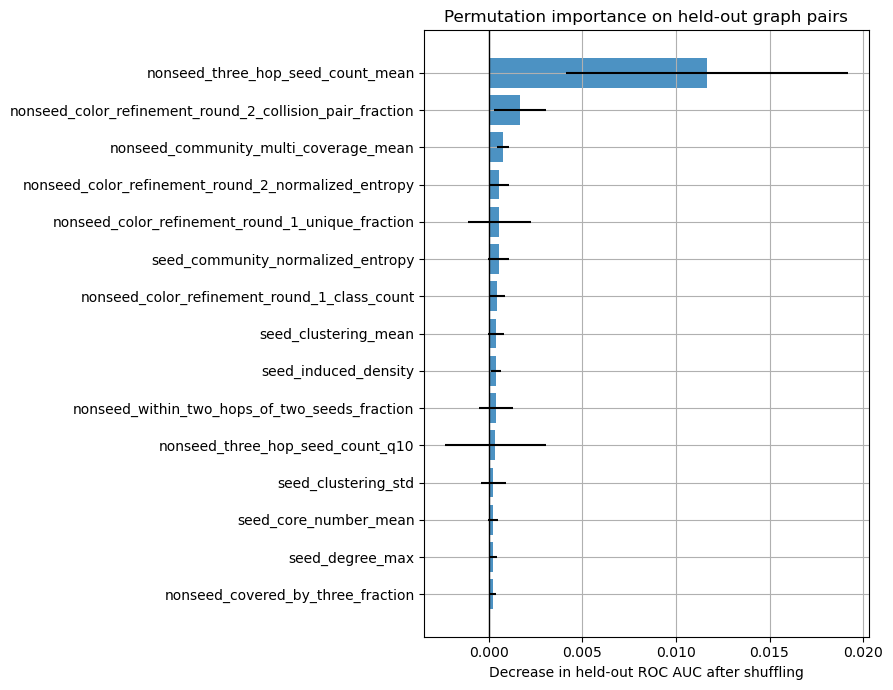

In [41]:
top_importance = importance_df.head(15).sort_values("importance_mean")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"],
    alpha=0.8,
)
ax.axvline(0, color="black", linewidth=1)
ax.set(
    title="Permutation importance on held-out graph pairs",
    xlabel="Decrease in held-out ROC AUC after shuffling",
)
plt.tight_layout()
plt.show()


## Reading the results

1. Check the success rate first. A threshold that produces almost only one class will make classification metrics unstable; adjust `SUCCESS_THRESHOLD` if needed.
2. Compare the random forest with the class-prior baseline in grouped cross-validation. ROC AUC and average precision evaluate ranking, while balanced accuracy evaluates the default 0.5 probability cutoff.
3. Use the calibration plot to decide whether the predicted probabilities can be interpreted as useful confidence estimates. Good ranking does not guarantee good calibration.
4. Treat permutation importance as evidence only when the random forest consistently beats the baseline. Correlated features may share or hide one another's importance.
5. Graph-level columns describe differences among graph pairs. Seed-level columns are the features that can distinguish candidate sets within the same graph pair.
6. H0 remains a diagnostic outcome because its accuracy requires the hidden ground-truth correspondence; it is deliberately excluded from the predictors.
